In [1]:
import numpy as np
import matplotlib.pyplot as plt
import glob, os
from PIL import Image

ROOT = '/kaggle/input'
IMG_SIZE = 100      # every image is resized to 100 x 100 pixels
N_TRAIN = 500       # number of GOOD images used to learn what 'normal' looks like

def find_folder(split, cls):
    hits = glob.glob(ROOT + '/**/' + split + '/' + cls, recursive=True)
    return hits[0]

ok_train_dir  = find_folder('train', 'ok_front')
def_train_dir = find_folder('train', 'def_front')
ok_test_dir   = find_folder('test', 'ok_front')
def_test_dir  = find_folder('test', 'def_front')

def load_image(path):
    img = Image.open(path).convert('L').resize((IMG_SIZE, IMG_SIZE))
    return np.asarray(img, dtype=float) / 255.0     # brightness from 0 (black) to 1 (white)

def load_folder(folder, n=None, start=0):
    files = sorted(glob.glob(folder + '/*'))
    files = files[start:] if n is None else files[start:start + n]
    return np.array([load_image(f) for f in files]), files

good_imgs, good_files = load_folder(ok_train_dir, N_TRAIN)
X = good_imgs.reshape(N_TRAIN, -1).T     # each COLUMN is one image
print('Data matrix X shape (pixels x images):', X.shape)

Data matrix X shape (pixels x images): (10000, 500)


## Stage 1: Data and Matrix Representation (Member 1)


In [2]:
print(ok_train_dir)
print(def_train_dir)
print(ok_test_dir)
print(def_test_dir)
print('Good train images  :', len(glob.glob(ok_train_dir + '/*')))
print('Defect train images:', len(glob.glob(def_train_dir + '/*')))
print('Good test images   :', len(glob.glob(ok_test_dir + '/*')))
print('Defect test images :', len(glob.glob(def_test_dir + '/*')))

/kaggle/input/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/train/ok_front
/kaggle/input/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/train/def_front
/kaggle/input/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/test/ok_front
/kaggle/input/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/test/def_front
Good train images  : 2875
Defect train images: 3758
Good test images   : 262
Defect test images : 453


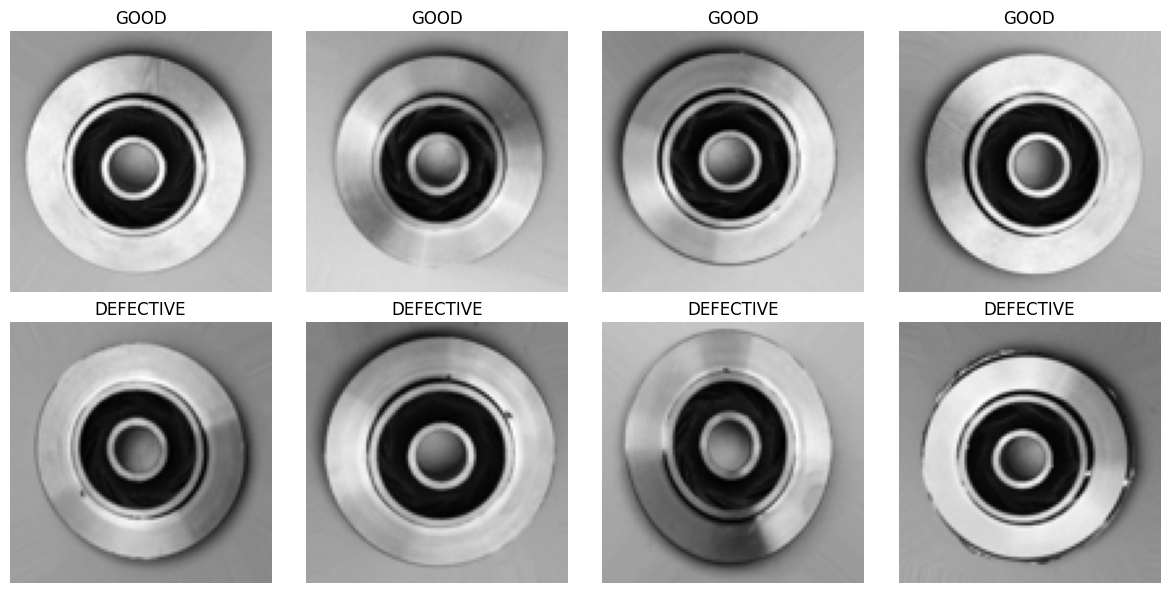

In [3]:
bad_imgs, _ = load_folder(def_train_dir, 4)
fig, ax = plt.subplots(2, 4, figsize=(12, 6))
for i in range(4):
    ax[0, i].imshow(good_imgs[i], cmap='gray'); ax[0, i].set_title('GOOD');      ax[0, i].axis('off')
    ax[1, i].imshow(bad_imgs[i],  cmap='gray'); ax[1, i].set_title('DEFECTIVE'); ax[1, i].axis('off')
plt.tight_layout(); plt.show()

In [4]:
print('One image is a', good_imgs[0].shape, 'matrix of pixel brightness')
print(np.round(good_imgs[0][:5, :5], 2))     # top-left 5 x 5 corner
print('Flattened into a column of length', good_imgs[0].size)

One image is a (100, 100) matrix of pixel brightness
[[0.6  0.6  0.59 0.59 0.59]
 [0.6  0.6  0.6  0.59 0.59]
 [0.6  0.6  0.6  0.6  0.6 ]
 [0.61 0.6  0.6  0.6  0.6 ]
 [0.6  0.6  0.6  0.6  0.6 ]]
Flattened into a column of length 10000


In [5]:
print('X shape:', X.shape, '-> each COLUMN is one image, each ROW is one pixel position')
print(X[:5, :5].round(2))

X shape: (10000, 500) -> each COLUMN is one image, each ROW is one pixel position
[[0.6  0.65 0.52 0.61 0.89]
 [0.6  0.65 0.52 0.61 0.89]
 [0.59 0.65 0.51 0.61 0.89]
 [0.59 0.64 0.51 0.62 0.89]
 [0.59 0.64 0.51 0.62 0.89]]


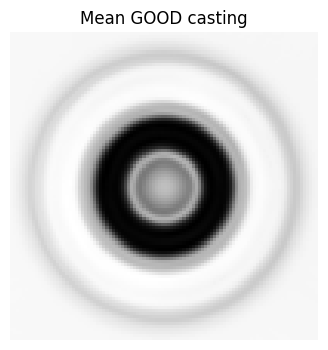

Mean of centered data (should be ~0): 0.0


In [6]:
mean_img = X.mean(axis=1, keepdims=True)      # average of all 500 columns
Xc = X - mean_img                             # subtract the average from every image

plt.figure(figsize=(4, 4))
plt.imshow(mean_img.reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
plt.title('Mean GOOD casting'); plt.axis('off'); plt.show()
print('Mean of centered data (should be ~0):', round(float(Xc.mean()), 10))

## Stage 2: RREF, LU, Rank, Basis and Gram–Schmidt (Member 2)


In [7]:
import sympy as sp

small = []
for f in good_files[:5]:
    im = Image.open(f).convert('L').resize((8, 8))
    small.append(np.asarray(im, dtype=int).flatten())   # 64 whole numbers per image
small = np.array(small).T                                # 64 x 5

blend = small[:, 0] + small[:, 1]                         # a 'fake' image = image1 + image2
A = np.column_stack([small, blend])                       # 64 x 6
print('A shape:', A.shape)

A_sym = sp.Matrix(A.tolist())
R, pivots = A_sym.rref()
print('Pivot columns:', pivots)
sp.pprint(R[:6, :]) 

A shape: (64, 6)
Pivot columns: (0, 1, 2, 3, 4)
⎡1  0  0  0  0  1⎤
⎢                ⎥
⎢0  1  0  0  0  1⎥
⎢                ⎥
⎢0  0  1  0  0  0⎥
⎢                ⎥
⎢0  0  0  1  0  0⎥
⎢                ⎥
⎢0  0  0  0  1  0⎥
⎢                ⎥
⎣0  0  0  0  0  0⎦


In [8]:
rank = A_sym.rank()
nullity = A.shape[1] - rank
print('Rank =', rank, '  Nullity =', nullity)
null_vec = A_sym.nullspace()[0]
print('Null space vector:', list(null_vec))

Rank = 5   Nullity = 1
Null space vector: [-1, -1, 0, 0, 0, 1]


In [9]:
from scipy.linalg import lu
G = (A.T @ A).astype(float)          # 6 x 6 square matrix of dot products between images
P, L, U = lu(G)
np.set_printoptions(precision=2, suppress=True)
print('L =\n', L)
print('U =\n', U)
print('P @ L @ U equals G?', np.allclose(P @ L @ U, G))
print('Last pivot of U (relative size):', U[-1, -1] / U[0, 0])

L =
 [[ 1.    0.    0.    0.    0.    0.  ]
 [ 0.51  1.    0.    0.    0.    0.  ]
 [ 0.46  0.46  1.    0.    0.    0.  ]
 [ 0.49  0.73  0.66  1.    0.    0.  ]
 [ 0.49 -0.34 -0.1   0.42  1.    0.  ]
 [ 0.49 -1.   -0.    0.    0.    1.  ]]
U =
 [[3307440.   3261889.   3020224.   3200979.   3246328.   6569329.  ]
 [      0.    -21221.43   -4811.42   -2546.5   -14162.71  -21221.43]
 [      0.         0.     51001.78   33648.82   -5270.64       0.  ]
 [      0.         0.         0.     84912.71   36010.15       0.  ]
 [      0.         0.         0.         0.    130232.87      -0.  ]
 [      0.         0.         0.         0.         0.         0.  ]]
P @ L @ U equals G? True
Last pivot of U (relative size): 0.0


In [10]:
print('Exact rank of X:', np.linalg.matrix_rank(X))
s = np.linalg.svd(X, compute_uv=False)
print('Effective rank (directions bigger than 1% of the largest):', int(np.sum(s > 0.01 * s[0])))

Exact rank of X: 500
Effective rank (directions bigger than 1% of the largest): 56


In [11]:
basis_idx = list(pivots[:5])         # the independent (pivot) images found by RREF
B = X[:, basis_idx]                  # full 100 x 100 versions of those images
print('Basis matrix B shape:', B.shape)

Basis matrix B shape: (10000, 5)


Q^T Q =
 [[ 1.  0.  0.  0.  0.]
 [ 0.  1. -0. -0. -0.]
 [ 0. -0.  1. -0. -0.]
 [ 0. -0. -0.  1. -0.]
 [ 0. -0. -0. -0.  1.]]
Matches numpy QR (up to sign)? True


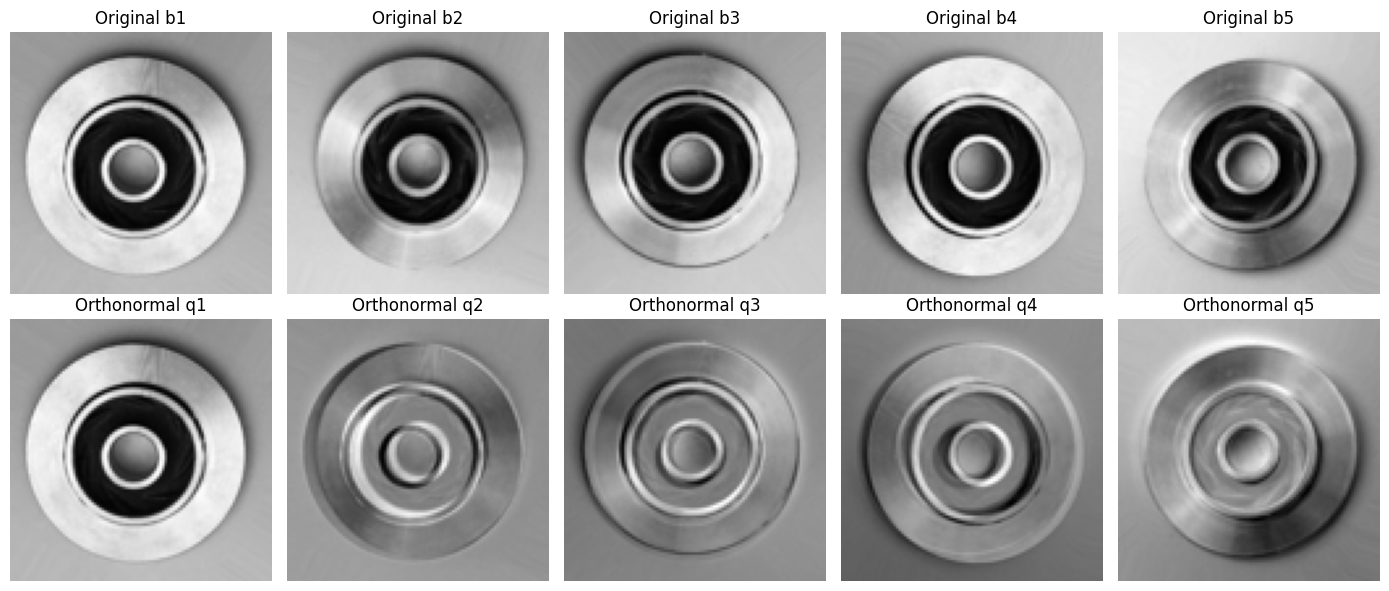

In [12]:
def gram_schmidt(B):
    Q = np.zeros_like(B)
    for j in range(B.shape[1]):
        v = B[:, j].copy()
        for i in range(j):
            v = v - (Q[:, i] @ B[:, j]) * Q[:, i]   # remove the part along earlier q's
        Q[:, j] = v / np.linalg.norm(v)              # make length 1
    return Q

Q_gs = gram_schmidt(B)
print('Q^T Q =\n', np.round(Q_gs.T @ Q_gs, 4))
Q_np, _ = np.linalg.qr(B)
print('Matches numpy QR (up to sign)?', np.allclose(np.abs(Q_gs), np.abs(Q_np)))

fig, ax = plt.subplots(2, 5, figsize=(14, 6))
for j in range(5):
    ax[0, j].imshow(B[:, j].reshape(IMG_SIZE, IMG_SIZE), cmap='gray');    ax[0, j].set_title(f'Original b{j+1}');   ax[0, j].axis('off')
    ax[1, j].imshow(Q_gs[:, j].reshape(IMG_SIZE, IMG_SIZE), cmap='gray'); ax[1, j].set_title(f'Orthonormal q{j+1}'); ax[1, j].axis('off')
plt.tight_layout(); plt.show()

## Stage 3: Eigenvalues, Diagonalization, Projection and Least Squares (Member 3)

In [13]:
mean_img = X.mean(axis=1, keepdims=True)
Xc = X - mean_img
S = Xc.T @ Xc                       # 500 x 500
print('S shape:', S.shape, '  symmetric?', np.allclose(S, S.T))

S shape: (500, 500)   symmetric? True


In [14]:
eigvals, U = np.linalg.eigh(S)              # eigh = for symmetric matrices
order = np.argsort(eigvals)[::-1]           # largest first
eigvals = eigvals[order]; U = U[:, order]
print('Top 10 eigenvalues:', np.round(eigvals[:10], 2))
print('Smallest eigenvalue (~0):', eigvals[-1])

Top 10 eigenvalues: [25163.16 23648.83 12254.39  6909.92  6503.26  6140.84  4946.02  4269.98
  3501.82  2455.58]
Smallest eigenvalue (~0): 5.589399557572804e-14


In [15]:
D = U.T @ S @ U
print('U^T S U is diagonal?', np.allclose(D, np.diag(eigvals), atol=1e-6))
print('Diagonal entries = eigenvalues?', np.allclose(np.diag(D), eigvals))

U^T S U is diagonal? True
Diagonal entries = eigenvalues? True


k for 95% variance: 77


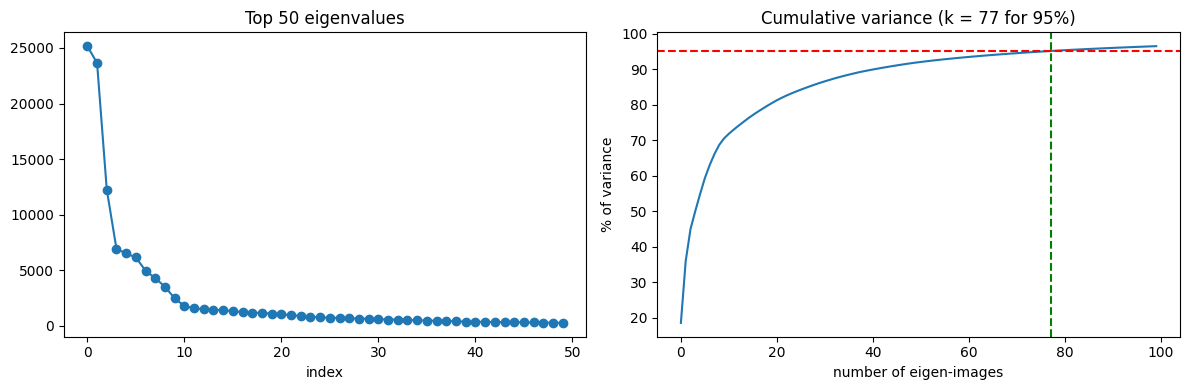

In [16]:
var_ratio = eigvals / eigvals.sum()
cum_var = np.cumsum(var_ratio)
k = int(np.searchsorted(cum_var, 0.95) + 1)
print('k for 95% variance:', k)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(eigvals[:50], 'o-'); ax[0].set_title('Top 50 eigenvalues'); ax[0].set_xlabel('index')
ax[1].plot(cum_var[:100] * 100); ax[1].axhline(95, color='r', ls='--'); ax[1].axvline(k, color='g', ls='--')
ax[1].set_title(f'Cumulative variance (k = {k} for 95%)')
ax[1].set_xlabel('number of eigen-images'); ax[1].set_ylabel('% of variance')
plt.tight_layout(); plt.show()

V shape: (10000, 77)   orthonormal? True


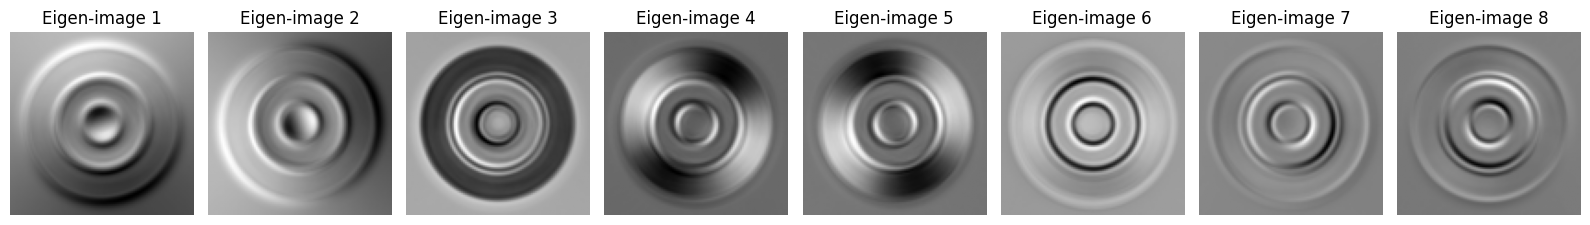

In [17]:
V = Xc @ U[:, :k]                     # convert small eigenvectors to image-sized ones
V = V / np.linalg.norm(V, axis=0)     # unit length
print('V shape:', V.shape, '  orthonormal?', np.allclose(V.T @ V, np.eye(k), atol=1e-6))

fig, ax = plt.subplots(1, 8, figsize=(16, 3))
for i in range(8):
    ax[i].imshow(V[:, i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray'); ax[i].set_title(f'Eigen-image {i+1}'); ax[i].axis('off')
plt.tight_layout(); plt.show() 

In [18]:
x = load_image(sorted(glob.glob(ok_test_dir + '/*'))[0]).reshape(-1, 1)   # a NEW good image
c = V.T @ (x - mean_img)              # projection coefficients
x_hat = mean_img + V @ c              # projection = reconstruction
print('Coefficients:', c.shape[0], 'numbers instead of', x.shape[0], 'pixels')

c_ls, *_ = np.linalg.lstsq(V, x - mean_img, rcond=None)
print('Projection coefficients = least-squares coefficients?', np.allclose(c, c_ls))

r = (x - mean_img) - V @ c
print('Residual orthogonal to the subspace? max |V^T r| =', float(np.abs(V.T @ r).max()))

p1 = V @ (V.T @ (x - mean_img)); p2 = V @ (V.T @ p1)
print('Projecting twice changes nothing (P^2 = P)?', np.allclose(p1, p2))

Coefficients: 77 numbers instead of 10000 pixels
Projection coefficients = least-squares coefficients? True
Residual orthogonal to the subspace? max |V^T r| = 3.534162979629274e-14
Projecting twice changes nothing (P^2 = P)? True


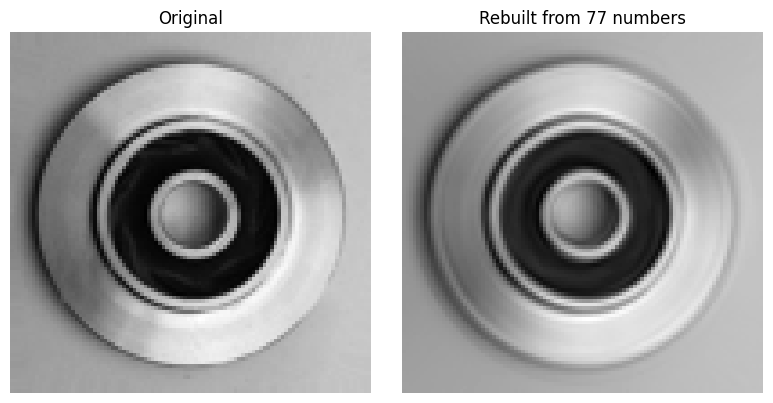

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(x.reshape(IMG_SIZE, IMG_SIZE), cmap='gray');     ax[0].set_title('Original');                    ax[0].axis('off')
ax[1].imshow(x_hat.reshape(IMG_SIZE, IMG_SIZE), cmap='gray'); ax[1].set_title(f'Rebuilt from {k} numbers'); ax[1].axis('off')
plt.tight_layout(); plt.show()

## Stage 4: Defect Detection and Final Output (Member 4)

In [20]:
mean_img = X.mean(axis=1, keepdims=True)
Xc = X - mean_img
eigvals, U = np.linalg.eigh(Xc.T @ Xc)
order = np.argsort(eigvals)[::-1]
eigvals, U = eigvals[order], U[:, order]
k = int(np.searchsorted(np.cumsum(eigvals) / eigvals.sum(), 0.95) + 1)
V = Xc @ U[:, :k]
V = V / np.linalg.norm(V, axis=0)
print('Basis ready: k =', k)

Basis ready: k = 77


In [21]:
def reconstruct(x):
    x = x.reshape(-1, 1)
    return mean_img + V @ (V.T @ (x - mean_img))      # projection onto the GOOD subspace

def defect_score(x):
    x = x.reshape(-1, 1)
    return float(np.mean((x - reconstruct(x)) ** 2))  # mean squared reconstruction error

val_good, _ = load_folder(ok_train_dir, 200, start=N_TRAIN)   # 200 good images NOT used for learning
val_bad, _  = load_folder(def_train_dir, 200)                 # 200 defective images
s_good = np.array([defect_score(im) for im in val_good])
s_bad  = np.array([defect_score(im) for im in val_bad])
print('Average score GOOD     :', s_good.mean())
print('Average score DEFECTIVE:', s_bad.mean())

Average score GOOD     : 0.0020882407863360396
Average score DEFECTIVE: 0.0043910889387521876


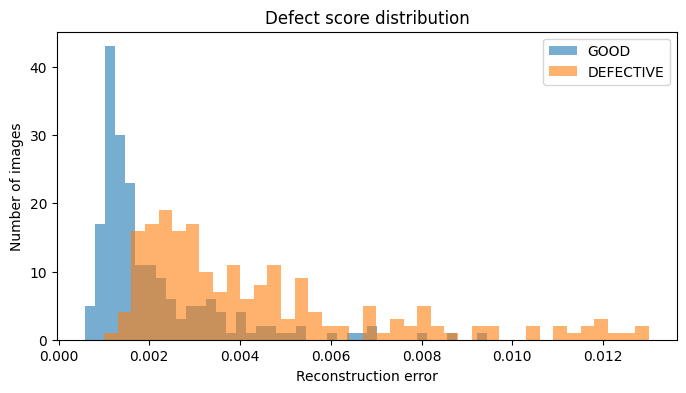

In [22]:
plt.figure(figsize=(8, 4))
plt.hist(s_good, bins=40, alpha=0.6, label='GOOD')
plt.hist(s_bad,  bins=40, alpha=0.6, label='DEFECTIVE')
plt.xlabel('Reconstruction error'); plt.ylabel('Number of images')
plt.title('Defect score distribution'); plt.legend(); plt.show()

In [23]:
candidates = np.linspace(min(s_good.min(), s_bad.min()), max(s_good.max(), s_bad.max()), 500)
best_acc, threshold = 0, None
for t in candidates:
    acc = (np.mean(s_good <= t) + np.mean(s_bad > t)) / 2   # balanced accuracy
    if acc > best_acc:
        best_acc, threshold = acc, t
print('Chosen threshold:', threshold, '  validation accuracy:', round(best_acc * 100, 2), '%')

Chosen threshold: 0.001805331236500492   validation accuracy: 78.5 %


TP=431  TN=173  FP=89  FN=22
TEST ACCURACY : 84.48 %
PRECISION     : 82.88 %
RECALL        : 95.14 %


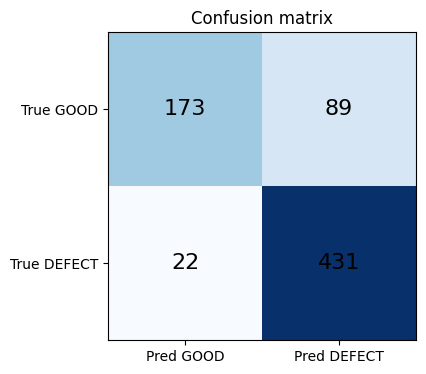

In [24]:
test_good, _ = load_folder(ok_test_dir)
test_bad,  _ = load_folder(def_test_dir)
t_good = np.array([defect_score(im) for im in test_good])
t_bad  = np.array([defect_score(im) for im in test_bad])

TN = int(np.sum(t_good <= threshold)); FP = int(np.sum(t_good > threshold))
TP = int(np.sum(t_bad  >  threshold)); FN = int(np.sum(t_bad <= threshold))
accuracy  = (TP + TN) / (TP + TN + FP + FN)
precision = TP / max(TP + FP, 1)
recall    = TP / max(TP + FN, 1)
print(f'TP={TP}  TN={TN}  FP={FP}  FN={FN}')
print('TEST ACCURACY :', round(accuracy * 100, 2), '%')
print('PRECISION     :', round(precision * 100, 2), '%')
print('RECALL        :', round(recall * 100, 2), '%')

cm = np.array([[TN, FP], [FN, TP]])
plt.figure(figsize=(4, 4)); plt.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=16)
plt.xticks([0, 1], ['Pred GOOD', 'Pred DEFECT']); plt.yticks([0, 1], ['True GOOD', 'True DEFECT'])
plt.title('Confusion matrix'); plt.show()

In [25]:
def inspect(path):
    x = load_image(path)
    x_hat = reconstruct(x).reshape(IMG_SIZE, IMG_SIZE)
    score = defect_score(x)
    heat = np.abs(x - x_hat)                         # where the image differs from 'good'
    verdict = 'DEFECTIVE' if score > threshold else 'GOOD'
    fig, ax = plt.subplots(1, 3, figsize=(13, 4))
    ax[0].imshow(x, cmap='gray');     ax[0].set_title('Input image')
    ax[1].imshow(x_hat, cmap='gray'); ax[1].set_title('Rebuilt from GOOD patterns')
    ax[2].imshow(heat, cmap='hot');   ax[2].set_title('Defect heatmap (bright = problem)')
    for a in ax: a.axis('off')
    plt.suptitle(f'Verdict: {verdict}   (score {score:.5f}, threshold {threshold:.5f})', fontsize=14,
                 color='red' if verdict == 'DEFECTIVE' else 'green')
    plt.tight_layout(); plt.show()
    return verdict

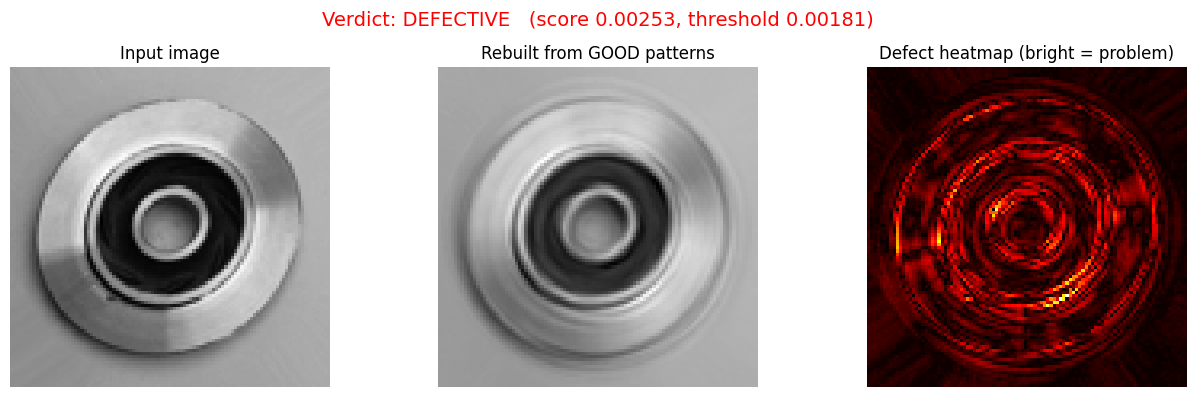

DEFECTIVE


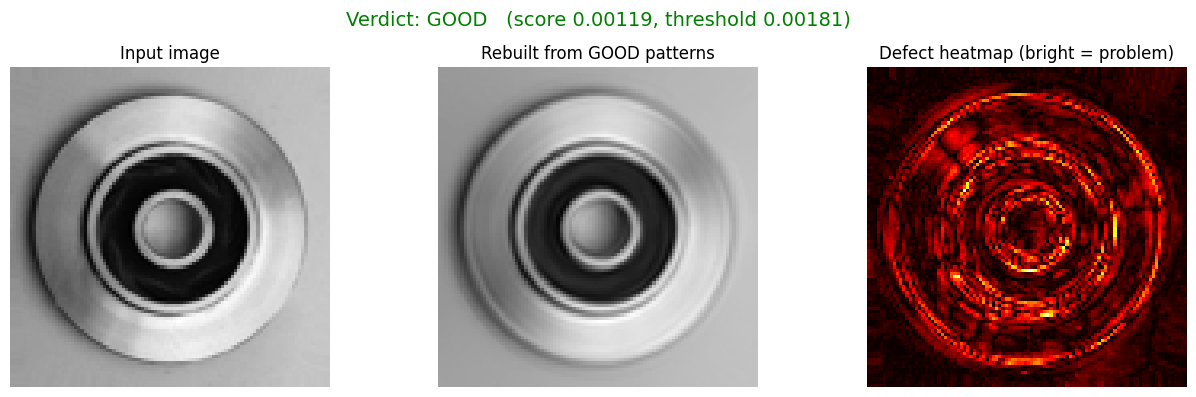

GOOD


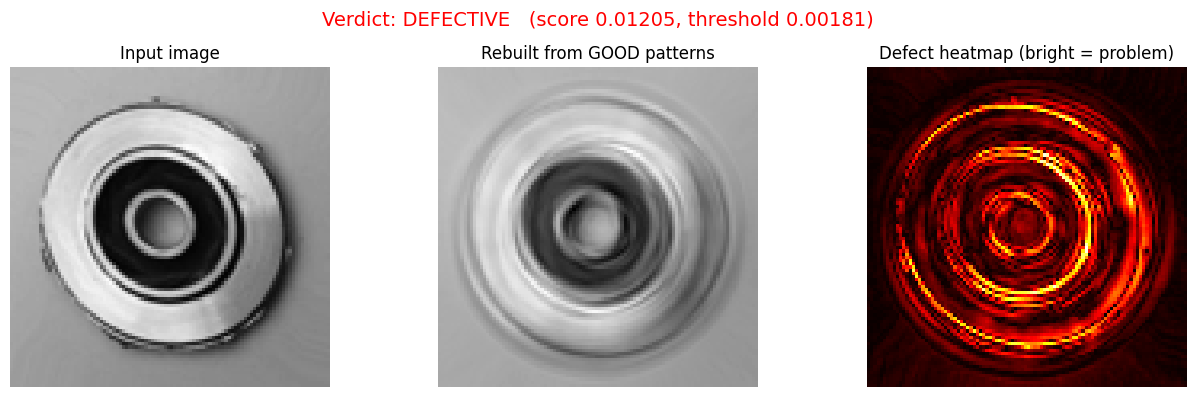

DEFECTIVE


In [26]:
defect_files = sorted(glob.glob(def_test_dir + '/*'))
good_files_test = sorted(glob.glob(ok_test_dir + '/*'))
print(inspect(defect_files[0]))
print(inspect(good_files_test[0]))
print(inspect(defect_files[10]))